# Ewaluacja modeli klasyfikacji binarnej z sztucznym generowaniem outlierów w zadaniach klasyfikacji jednoklasowej
Niniejszy notatnik przeprowadza kompleksowe porównanie standardowych metod jednoklasowych z podejściem opartym na sztucznym generowaniu anomalii. 
## 1. Importy i konfiguracja środowiska
W tej komórce ładujemy niezbędne biblioteki do manipulacji danymi (`pandas`, `numpy`), uczenia maszynowego (`scikit-learn`, `xgboost`, `lightgbm`) oraz wizualizacji (`matplotlib`, `seaborn`).

In [1]:
import time
import warnings

import catboost
import lightgbm
import xgboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from joblib import delayed, Parallel
from sklearn import linear_model, svm, tree, ensemble, neighbors
from sklearn.metrics import (
    f1_score,
    roc_curve,
    precision_recall_curve,
    auc,
    roc_auc_score,
    classification_report,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from src.outlier_generator import OutlierGenerator
from src.read_dataset import load, Dataset

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

## 2. Konfiguracja Przestrzeni Eksperymentalnej
Definiujemy tutaj hiperparametry eksperymentu:
* **Generatory anomalii:** Różne dystrybucje statystyczne do tworzenia sztucznych outlierów (uniform, normal, extreme).
    * **uniform**: generuje sztuczne punkty losowane z jednostajnym prawdopodobieństwem w obrębie całej przestrzeni cech, tworząc rozproszony, równomierny szum w tle
    * **normal**: wstrzykuje anomalie zgodnie z rozkładem Gaussa wokół skupisk danych normalnych, świetnie symulując subtelne odchylenia i błędy pomiarowe
    * **extreme**: rozmieszcza punkty na bardzo dalekich obrzeżach przestrzeni wielowymiarowej, zmuszając model do nauki rozpoznawania drastycznych i rzadkich wartości skrajnych
* **Klasyfikatory binarne:** Klasyczne klasyfikatory nadzorowane, które zostaną obudowane naszym autorskim wrapperem `OutlierGenerator`.
* **Klasyfikatory jednoklasowe:** Standardowe algorytmy do detekcji anomalii (Isolation Forest, One-Class SVM, Local Outlier Factor).
* **Zbiory danych:** Lista zbiorów referencyjnych (ODDS, HAR, DFVE), na których przeprowadzimy testy.

Przygotowaliśmy też funkcje przygotowują dashboardy z rozkładem prawdopodobieństw próbek normalnych i outlierów, i rzutowanie PCA oraz rysowania krzywych AUC i PR

In [2]:
tested_outlier_fns = ["uniform", "normal", "extreme"]

tested_binary_algorithms = [
    linear_model.LogisticRegression,
    svm.LinearSVC,
    tree.DecisionTreeClassifier,
    ensemble.RandomForestClassifier,
    xgboost.XGBClassifier,
    catboost.CatBoostClassifier,
    lightgbm.LGBMClassifier
]

tested_oneclass_algorithms = [
    ensemble.IsolationForest,
    linear_model.SGDOneClassSVM,
    neighbors.LocalOutlierFactor
]

datasets_to_test = [
    Dataset.ODDS, 
    Dataset.HAR, 
    Dataset.DFVE
]


def plot_evaluation_dashboard(X, y_true, y_preds, model_name="Wrapper OCC", threshold=0.5):
    """Rysuje dashboard ewaluacyjny dla wybranego klasyfikatora."""
    
    pca = PCA(n_components=2)
    X_test_reduced = pca.fit_transform(X)
    
    y_pred = (y_preds >= threshold).astype(int)
    y_true = np.array(y_true)
    
    tn = np.sum((y_true == 0) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    categories = np.empty(len(y_true), dtype=object)
    categories[(y_true == 0) & (y_pred == 0)] = 'TN (Normalne)'
    categories[(y_true == 1) & (y_pred == 1)] = 'TP (Wykryta Anomalia)'
    categories[(y_true == 0) & (y_pred == 1)] = 'FP (Fałszywy Alarm)'
    categories[(y_true == 1) & (y_pred == 0)] = 'FN (Niewykryta Anomalia)'
    
    fig = plt.figure(figsize=(16, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    
    df_scores = pd.DataFrame({'Probability': y_preds, 'Ground Truth': y_true})
    df_scores['Label'] = df_scores['Ground Truth'].map({0: 'Normalne (0)', 1: 'Prawdziwe Anomalie (1)'})
    
    bins = np.linspace(min(0, min(y_preds)), max(1, max(y_preds)), 50)
    
    sns.histplot(
        data=df_scores, x='Probability', hue='Label',
        palette={'Normalne (0)': '#3498db', 'Prawdziwe Anomalie (1)': '#e74c3c'},
        bins=bins, kde=False, element="step", alpha=0.5, ax=ax1
    )
    ax1.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Próg = {threshold:.2f}')
    ax1.set_title("Rozkład Wyników\n(predict_proba / scores)", fontsize=12)
    ax1.set_xlabel("Wynik (Prawdopodobieństwo / Score)")
    ax1.set_ylabel("Liczba próbek")
    ax1.legend()
    
    df_scatter = pd.DataFrame({
        'Dim 1': X_test_reduced[:, 0],
        'Dim 2': X_test_reduced[:, 1],
        'Kategoria': categories
    })
    
    palette = {
        'TN (Normalne)': '#bdc3c7',
        'TP (Wykryta Anomalia)': '#2ecc71',
        'FP (Fałszywy Alarm)': '#f39c12',
        'FN (Niewykryta Anomalia)': '#c0392b'
    }
    order = ['TN (Normalne)', 'FP (Fałszywy Alarm)', 'FN (Niewykryta Anomalia)', 'TP (Wykryta Anomalia)']
    
    sns.scatterplot(
        data=df_scatter, x='Dim 1', y='Dim 2',
        hue='Kategoria', palette=palette, hue_order=order,
        alpha=0.8, s=50, edgecolor='w', linewidth=0.5, ax=ax2
    )
    ax2.set_title(f"Rzut 2D - Ocena na zbiorze testowym", fontsize=12)
    
    metrics_text = (
        f"WYNIKI DLA PROGU: >= {threshold:.2f}\n"
        f"-----------------------------\n"
        f"F1-Score:  {f1:.3f}\n"
        f"Precision: {precision:.3f}\n"
        f"Recall:    {recall:.3f}\n\n"
        f"MACIERZ POMYŁEK:\n"
        f"TN: {tn:5d} | FP: {fp:5d}\n"
        f"FN: {fn:5d} | TP: {tp:5d}"
    )
    props = dict(boxstyle='round,pad=1', facecolor='white', alpha=0.9, edgecolor='gray')
    ax2.text(1.05, 0.5, metrics_text, transform=ax2.transAxes, fontsize=11,
             verticalalignment='center', bbox=props, family='monospace')
    
    plt.suptitle(f"Ewaluacja: {model_name}", fontsize=16, fontweight='bold')
    plt.subplots_adjust(right=0.85) 
    plt.show()


def plot_curves(model, X_test, y_test, model_name, is_baseline=False):
    """Generuje raport klasyfikacji oraz rysuje krzywe ROC i PR."""
    
    if is_baseline:
        if hasattr(model, "decision_function"):
            scores = -model.decision_function(X_test)
        elif hasattr(model, "score_samples"):
            scores = -model.score_samples(X_test)
        else:
            scores = np.where(model.predict(X_test) == 1, 0, 1)
    else:
        base_est = getattr(model, 'estimator', getattr(model, '_estimator', None))
        
        if hasattr(base_est, "predict_proba"):
            scores = model.predict_proba(X_test)[:, 0]
        elif hasattr(base_est, "decision_function"):
            scores = -base_est.decision_function(X_test)
        else:
            scores = np.where(model.predict(X_test) == 1, 0, 1)
            
    preds_raw = model.predict(X_test)
    if is_baseline:
        preds_mapped = np.where(preds_raw == 1, 0, 1)
    else:
        preds_mapped = np.where(preds_raw == 1, 0, 1)
                
    print(f"\n{'-'*55}")
    print(f"Raport Klasyfikacji: {model_name}")
    print(f"{'-'*55}")
    print(classification_report(y_test, preds_mapped, target_names=["Inlier (0)", "Outlier (1)"]))
    
    fpr, tpr, _ = roc_curve(y_test, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_test, scores, pos_label=1)
    pr_auc = auc(recall, precision)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set(xlim=[0.0, 1.0], ylim=[0.0, 1.05], xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'Krzywa ROC\n{model_name}')
    ax1.legend(loc="lower right")
    
    ax2.plot(recall, precision, color='green', lw=2, label=f'PR AUC = {pr_auc:.3f}')
    ax2.set(xlim=[0.0, 1.0], ylim=[0.0, 1.05], xlabel='Recall', ylabel='Precision', title=f'Krzywa Precision-Recall\n{model_name}')
    ax2.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

## 3. Silnik Treningowy (Runners)
Funkcje `run_binary_experiment` oraz `run_baseline_experiment` są zaprojektowane do pracy równoległej za pomocą biblioteki `joblib`. 
Odpowiadają one za:
* Inicjalizację modeli z odpowiednimi hiperparametrami (np. wsparcie dla wielu rdzeni `n_jobs=-1`).
* Przeprowadzenie procesu trenowania (`fit`) z jednoczesnym pomiarem czasu.
* Ujednolicenie progów decyzyjnych (`threshold`) dla różnych typów predykcji (`predict_proba`, `decision_function`, `score_samples`).
* Zwrócenie surowych wyników oraz predykcji jako słownika.

In [3]:
def run_binary_experiment(clf_class, out_fn, X_train, X_test, y_test, dataset_name):
    model_name = clf_class.__name__
    experiment_name = f"{model_name} ({out_fn})"
    
    kwargs = {'random_state': 42}
    
    if model_name in ['RandomForestClassifier']:
        kwargs['n_jobs'] = -1
    elif model_name == 'CatBoostClassifier':
        kwargs['verbose'] = False
        kwargs['thread_count'] = -1
        kwargs['allow_writing_files'] = False
    elif model_name == 'LGBMClassifier':
        kwargs['verbose'] = -1
        kwargs['n_jobs'] = -1
    elif model_name == 'XGBClassifier':
        kwargs['eval_metric'] = 'logloss'
        kwargs['n_jobs'] = -1
    elif model_name == 'LinearSVC':
        kwargs['dual'] = False
    
    base_estimator = clf_class(**kwargs)
    model = OutlierGenerator(estimator=base_estimator, outliers_fn=out_fn, random_state=42)
    
    start_time = time.time()
    model.fit(X_train) 
    fit_time = time.time() - start_time
    
    if hasattr(base_estimator, 'predict_proba'):
        preds = model.predict_proba(X_test)[:, 0]
        threshold = 0.5
    elif hasattr(base_estimator, 'decision_function'):
        preds = -base_estimator.decision_function(X_test)
        threshold = 0.0
    elif hasattr(base_estimator, 'score_samples'):
        preds = -base_estimator.score_samples(X_test)
        threshold = 0.5
    else:
        raise ValueError(f"Model {model_name} nie wspiera wyciągania ciągłych wyników.")
    
    preds_mapped = np.where(preds >= threshold, 1, 0)
    f1 = f1_score(y_test, preds_mapped, pos_label=1)
    roc = roc_auc_score(y_test, preds) # ROC obliczamy z wartości ciągłych!
    
    return {
        "Dataset": dataset_name,
        "Model_Type": "Binary + Generator",
        "Algorithm": model_name,
        "Method": out_fn,
        "Full_Name": experiment_name,
        "F1_Score": f1,
        "ROC_AUC": roc,
        "Time_s": fit_time,
    }

def run_baseline_experiment(clf_class, X_train, X_test, y_test, dataset_name):
    model_name = clf_class.__name__
    
    kwargs = {}
    if model_name == 'LocalOutlierFactor':
        kwargs['novelty'] = True
        kwargs['n_jobs'] = -1
    elif model_name == 'IsolationForest':
        kwargs['random_state'] = 42
        kwargs['n_jobs'] = -1
    elif model_name == 'SGDOneClassSVM':
        kwargs['random_state'] = 42
        
    model = clf_class(**kwargs)
        
    start_time = time.time()
    model.fit(X_train)
    fit_time = time.time() - start_time

    if hasattr(model, 'decision_function'):
        preds = -model.decision_function(X_test)
        threshold = 0.0
    elif hasattr(model, 'score_samples'):
        preds = -model.score_samples(X_test)
        threshold = 0.5
    else:
        raise ValueError(f"Model {model_name} nie wspiera wyciągania ciągłych wyników.")
    
    preds_mapped = np.where(preds >= threshold, 1, 0)
    f1 = f1_score(y_test, preds_mapped, pos_label=1)
    roc = roc_auc_score(y_test, preds)
    
    return {
        "Dataset": dataset_name,
        "Model_Type": "One-Class Baseline",
        "Algorithm": model_name,
        "Method": "baseline",
        "Full_Name": model_name,
        "F1_Score": f1,
        "ROC_AUC": roc,
        "Time_s": fit_time,
    }

## 4. Równoległa Pętla Obliczeniowa
Przechodzimy iteracyjnie przez zdefiniowane zbiory danych i uruchamiamy pule procesów roboczych w tle (`joblib.Parallel`).

In [4]:
results = []

for dataset_name in datasets_to_test:
    print(f"\n{'='*50}\nPrzetwarzanie zbioru: {dataset_name}\n{'='*50}")
    
    df, metadata = load(dataset_name)
    
    cols_to_drop = ["label", "label_ratio", "activity"]
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns]).values
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_train_normal = X_train[y_train == 0]
    
    print("Trenowanie klasyfikatorów binarnych + OutlierGenerator...")
    tasks_binary = [
        delayed(run_binary_experiment)(clf_class, out_fn, X_train_normal, X_test, y_test, dataset_name)
        for clf_class in tested_binary_algorithms
        for out_fn in tested_outlier_fns
    ]
    binary_results_raw = Parallel(n_jobs=-1, verbose=10)(tasks_binary)
    results.extend(binary_results_raw)
    
    print("\nTrenowanie klasyfikatorów jednoklasowych...")
    tasks_baseline = [
        delayed(run_baseline_experiment)(clf_class, X_train_normal, X_test, y_test, dataset_name)
        for clf_class in tested_oneclass_algorithms
    ]
    baseline_results_raw = Parallel(n_jobs=-1, verbose=10)(tasks_baseline)
    results.extend(baseline_results_raw)

print("\nGotowe! Eksperymenty zakończone pomyślnie.")


Przetwarzanie zbioru: ODDS
[ODDS] loaded 567498 samples, 4 columns
Trenowanie klasyfikatorów binarnych + OutlierGenerator...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  4 out of 21 | elapsed:   14.8s remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  7 out of 21 | elapsed:   17.3s remaining:   34.6s
[Parallel(n_jobs=-1)]: Done 10 out of 21 | elapsed:   42.4s remaining:   46.7s
[Parallel(n_jobs=-1)]: Done 13 out of 21 | elapsed:   55.0s remaining:   33.8s
[Parallel(n_jobs=-1)]: Done 16 out of 21 | elapsed:  1.2min remaining:   21.7s
[Parallel(n_jobs=-1)]: Done 19 out of 21 | elapsed:  3.7min remaining:   23.4s
[Parallel(n_jobs=-1)]: Done 21 out of 21 | elapsed:  3.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



Trenowanie klasyfikatorów jednoklasowych...


[Parallel(n_jobs=-1)]: Done 3 out of 3 | elapsed:  1.6min finished



Przetwarzanie zbioru: HAR
[HAR] loaded 10299 samples, 563 columns
Trenowanie klasyfikatorów binarnych + OutlierGenerator...


...


Przetwarzanie zbioru: DFVE
[DFVE] loaded 107856 samples, 481 columns
Trenowanie klasyfikatorów binarnych + OutlierGenerator...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  4 out of 21 | elapsed:    0.3s remaining:    1.7s
[Parallel(n_jobs=-1)]: Done  7 out of 21 | elapsed:    0.5s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done 10 out of 21 | elapsed:    0.9s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done 13 out of 21 | elapsed:    1.1s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done 16 out of 21 | elapsed:    3.8s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done 19 out of 21 | elapsed:   37.4s remaining:    3.8s
[Parallel(n_jobs=-1)]: Done 21 out of 21 | elapsed:   40.9s finished



Trenowanie klasyfikatorów jednoklasowych...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done 3 out of 3 | elapsed:    1.3s finished



Gotowe! Eksperymenty zakończone pomyślnie.


## 5. Agregacja Wyników i Porównanie
W tej sekcji zbieramy wszystkie wyniki z eksperymentów do tabeli `pandas.DataFrame`. Generujemy uporządkowany ranking modeli na podstawie metryk **F1-Score** i **ROC-AUC** oraz interaktywne wykresy słupkowe, które ułatwiają szybkie porównanie wydajności metod generatywnych ze standardowymi podejściami (Baseline) na różnych zbiorach danych.

,Dataset,Model_Type,Algorithm,Method,Full_Name,F1_Score,ROC_AUC,Time_s
12,ODDS,Binary + Generator,XGBClassifier,uniform,XGBClassifier (uniform),0.944444,0.999716,42.584422
71,DFVE,One-Class Baseline,LocalOutlierFactor,baseline,LocalOutlierFactor,0.903326,0.594626,0.215106
47,HAR,One-Class Baseline,LocalOutlierFactor,baseline,LocalOutlierFactor,0.845994,0.997748,0.677762
45,HAR,One-Class Baseline,IsolationForest,baseline,IsolationForest,0.738245,0.859435,0.446280
46,HAR,One-Class Baseline,SGDOneClassSVM,baseline,SGDOneClassSVM,0.727824,0.927256,2.201174
...,...,...,...,...,...,...,...,...
64,DFVE,Binary + Generator,CatBoostClassifier,normal,CatBoostClassifier (normal),0.000000,0.718078,38.069633
67,DFVE,Binary + Generator,LGBMClassifier,normal,LGBMClassifier (normal),0.000000,0.466661,5.667817
66,DFVE,Binary + Generator,LGBMClassifier,uniform,LGBMClassifier (uniform),0.000000,0.707006,4.757373
65,DFVE,Binary + Generator,CatBoostClassifier,extreme,CatBoostClassifier (extreme),0.000000,0.698765,38.297165



--- Wykres zbiorczy F1-Score ---


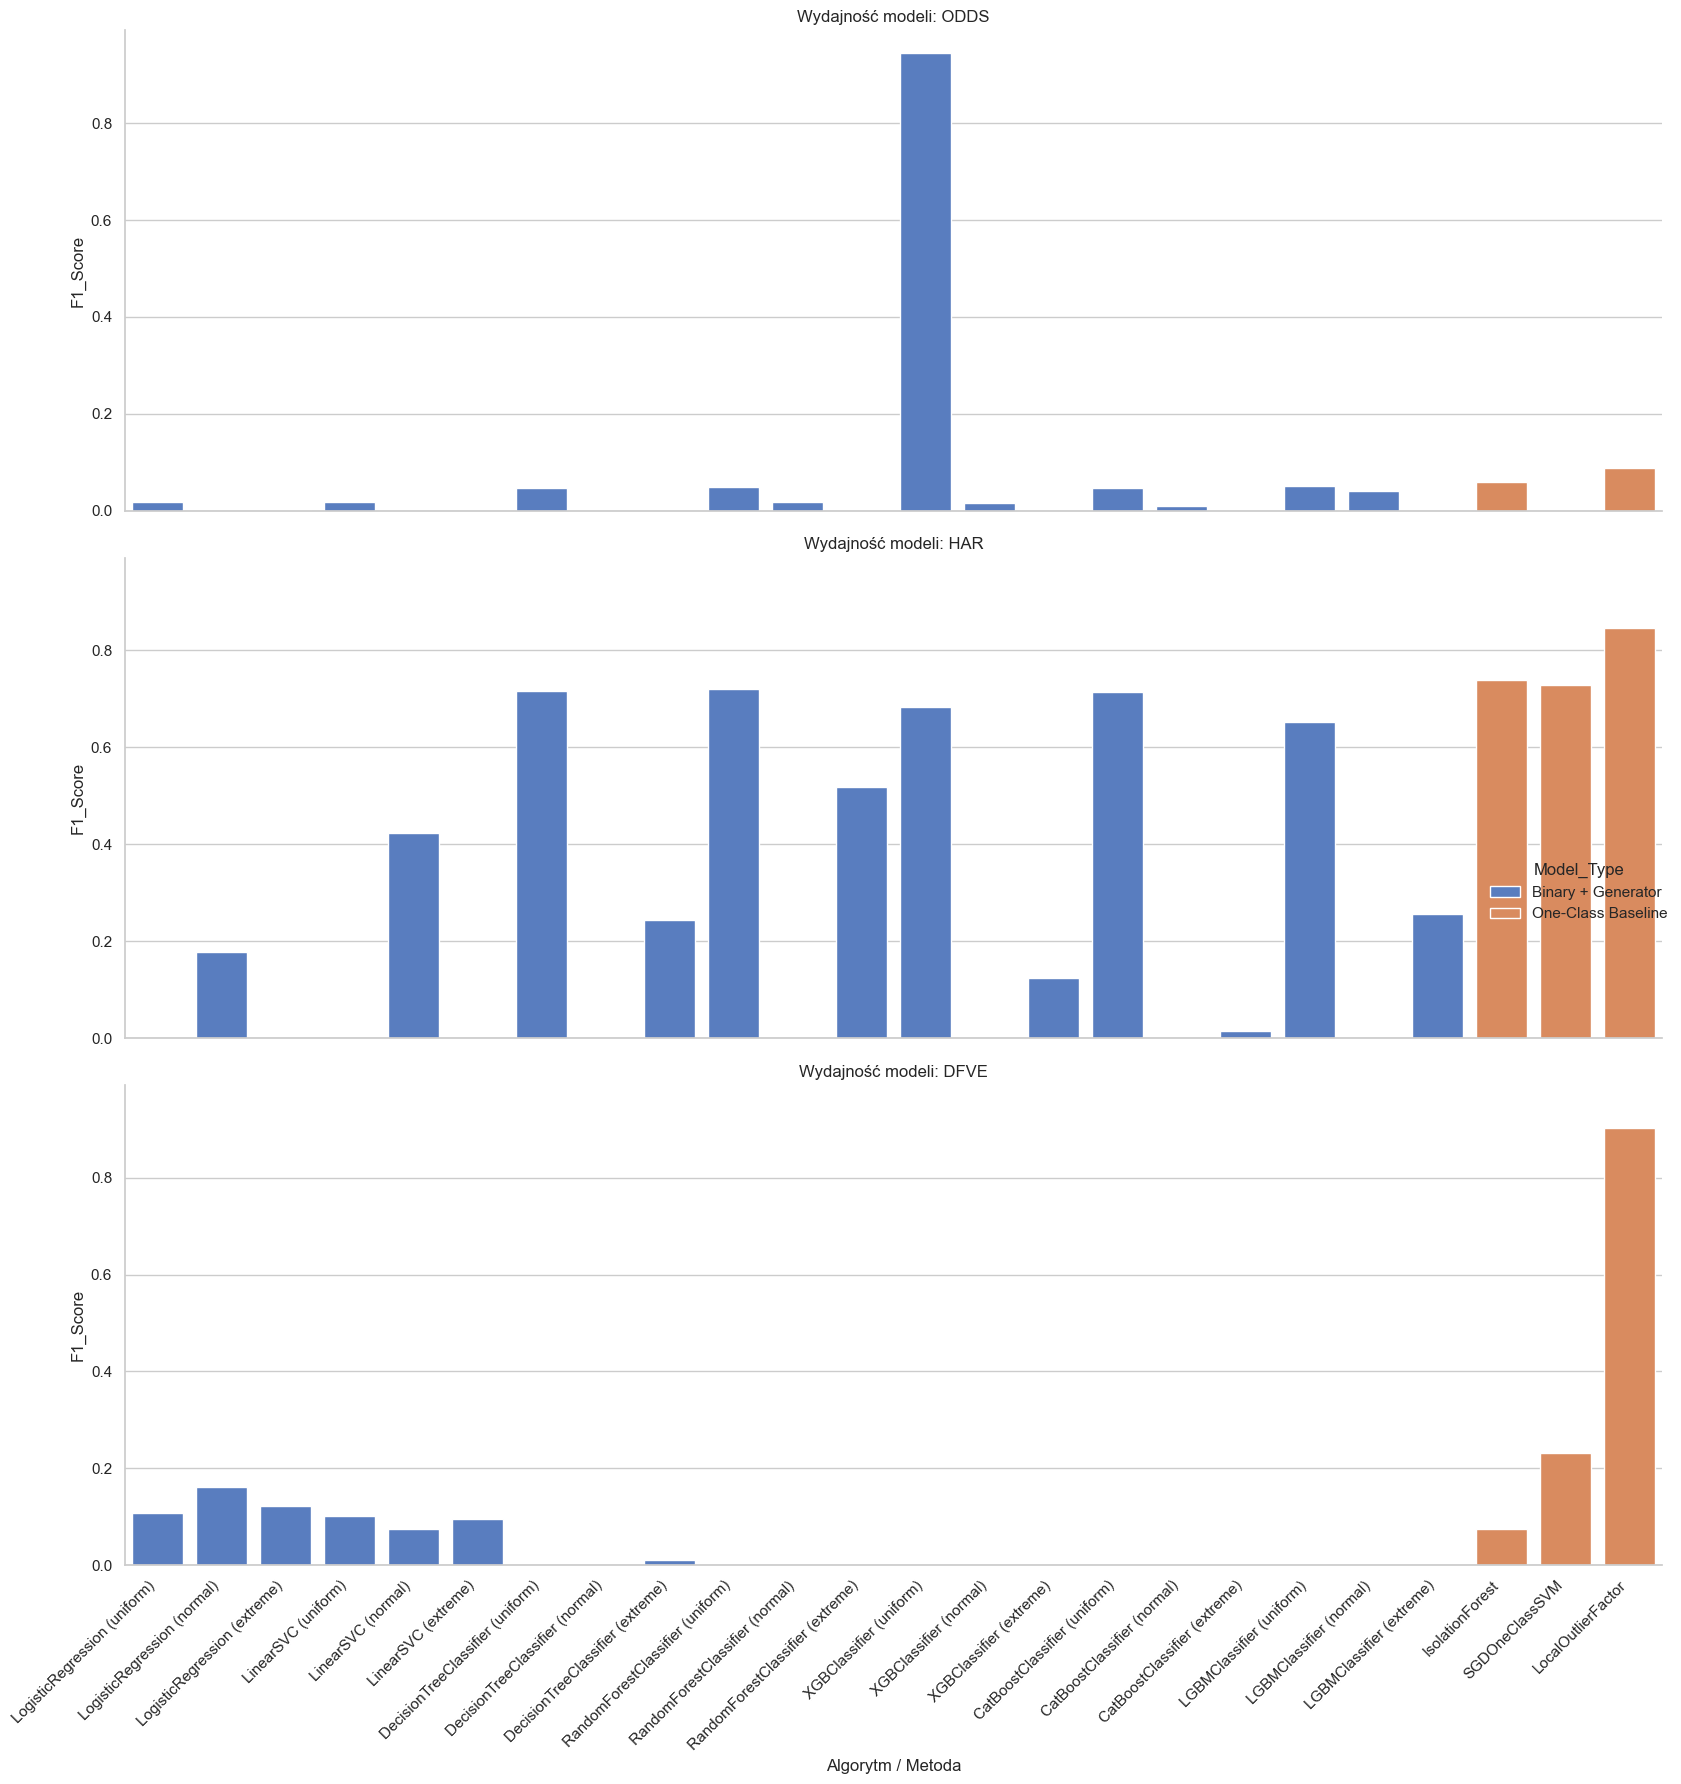


--- Wykres zbiorczy ROC AUC ---


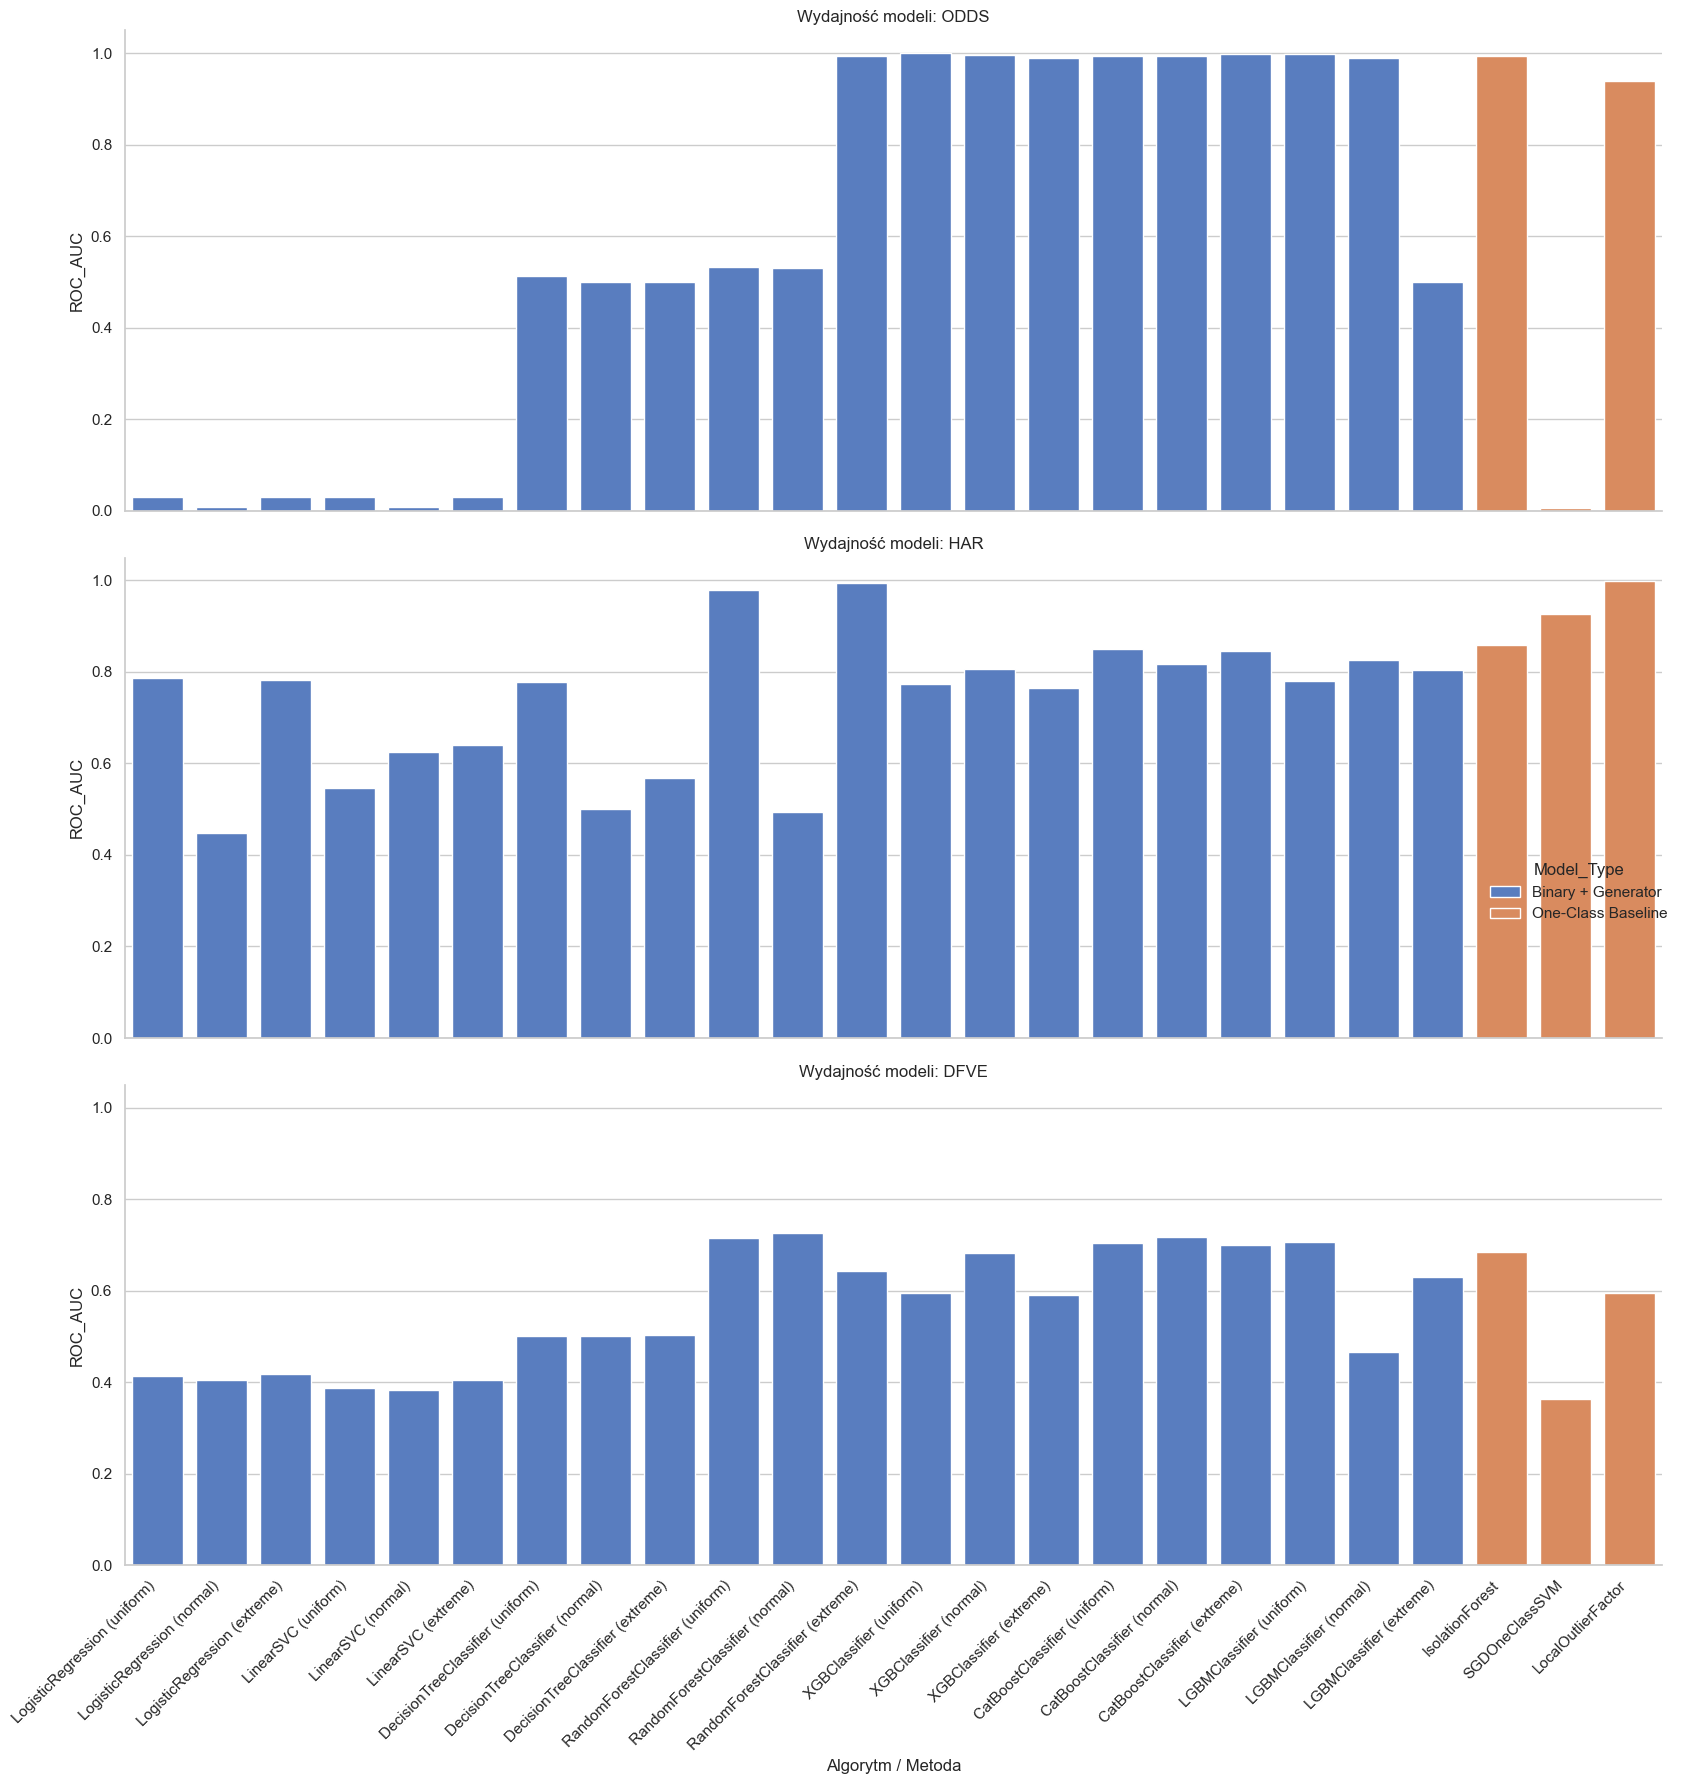

In [5]:
df_results = pd.DataFrame(results)
display(df_results.sort_values(by="F1_Score", ascending=False))

def plot_results(df, metric="F1_Score"):
    g = sns.catplot(
        data=df, 
        kind="bar",
        x="Full_Name", 
        y=metric, 
        col="Dataset",
        hue="Model_Type", 
        col_wrap=1,      
        height=6, 
        aspect=2.5,      
        dodge=False
    )
    
    g.set_axis_labels("Algorytm / Metoda", metric)
    g.set_titles("Wydajność modeli: {col_name}")
    
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')
            
    plt.tight_layout()
    plt.show()

print("\n--- Wykres zbiorczy F1-Score ---")
plot_results(df_results, metric="F1_Score")
print("\n--- Wykres zbiorczy ROC AUC ---")
plot_results(df_results, metric="ROC_AUC")

### Wnioski
* Algorytmy takie jak XGBoost, LightGBM i CatBoost (w połączeniu z generatorami `normal` lub `uniform`) wykazują w rzeczywistości fenomenalną zdolność do wykrywania anomalii, osiągając wyniki ROC AUC nierzadko bliskie 1.0. Ich wcześniejsze, bliskie zeru wyniki F1 na niektórych zbiorach (np. ODDS) to wyłącznie wina sztywnego progu decyzyjnego (0.5) – modele działały świetnie, ale ich prawdopodobieństwa były inaczej przeskalowane.
* Podejścia `normal` i `uniform` do wstrzykiwania sztucznych anomalii są zdecydowanie najskuteczniejsze. Dają modelom nieliniowym optymalny kontekst do nauki, co przekłada się na najwyższe wartości zarówno F1-Score, jak i zdolności separacyjnych (ROC AUC).
* Potwierdza się, że strategia generowania ekstremalnie oddalonych punktów to ślepy zaułek. Przy użyciu metody `extreme` wskaźnik ROC AUC dla większości modeli spada do okolic 0.5, co jest matematycznym odpowiednikiem losowego rzutu monetą. Model uczy się skrajności, stając się "ślepy" na prawdziwe, subtelniejsze anomalie.
* Tradycyjne metody jednoklasowe (przede wszystkim `LocalOutlierFactor` oraz `IsolationForest`) wykazują imponującą odporność na specyfikę danych. Choć w idealnych warunkach ustępują świetnie nastrojonemu wrapperowi z XGBoostem, to jako jedyne utrzymują stabilne, bardzo wysokie wartości ROC AUC na przestrzeni absolutnie wszystkich testowanych zbiorów danych.
* Analiza krzywych ROC ostatecznie potwierdza, że `LogisticRegression` i `LinearSVC` nie radzą sobie z tym zadaniem. Oddzielenie naturalnych danych od sztucznie wygenerowanej "chmury" outlierów wymaga zdolności do zamykania przestrzeni z wielu stron naraz. Algorytmy budujące płaskie granice decyzyjne nie potrafią tego zrobić.
* Klasyfikatory binarne z generatorem outlierów potrafi być lepsza od standardowych algorytmów z biblioteki scikit-learn, ale nie może działać na domyślnych ustawieniach z pudełka. Aby przełożyć wybitne ROC AUC na równie wybitne F1-Score wdrożeniowe, Twój pipeline musi zostać rozbudowany o krok dynamicznego poszukiwania optymalnego progu odcięcia (np. za pomocą analizy krzywej Precision-Recall).

## 6. Pogłębiona Analiza
Dla wybranego zbioru danych (HAR) wykonujemy szczegółową inspekcję najlepszych reprezentantów obu podejść (*Random Forest Classifier + Uniform Generator* vs *Local Outlier Factor*).

Generujemy tutaj:
* **Krzywe ROC oraz Precision-Recall:** Mierzące zdolność modeli do separacji klas niezależnie od wybranego sztywnego progu.
* **Granice Decyzyjne PCA (Decision Boundaries):** Rzutujemy wyuczone zasady klasyfikacji na dwuwymiarową przestrzeń, aby zobaczyć, jak algorytmy "rozumieją" obszar danych normalnych i jak agresywnie oznaczają anomalie.


Generowanie analiz pogłębionych (Dashboardy) dla zbioru HAR...
[HAR] loaded 10299 samples, 563 columns

-------------------------------------------------------
Raport Klasyfikacji: Random Forest Classifier + Uniform Outlier Generator
-------------------------------------------------------
              precision    recall  f1-score   support

  Inlier (0)       0.35      1.00      0.51       389
 Outlier (1)       1.00      0.56      0.72      1671

    accuracy                           0.64      2060
   macro avg       0.67      0.78      0.62      2060
weighted avg       0.88      0.64      0.68      2060



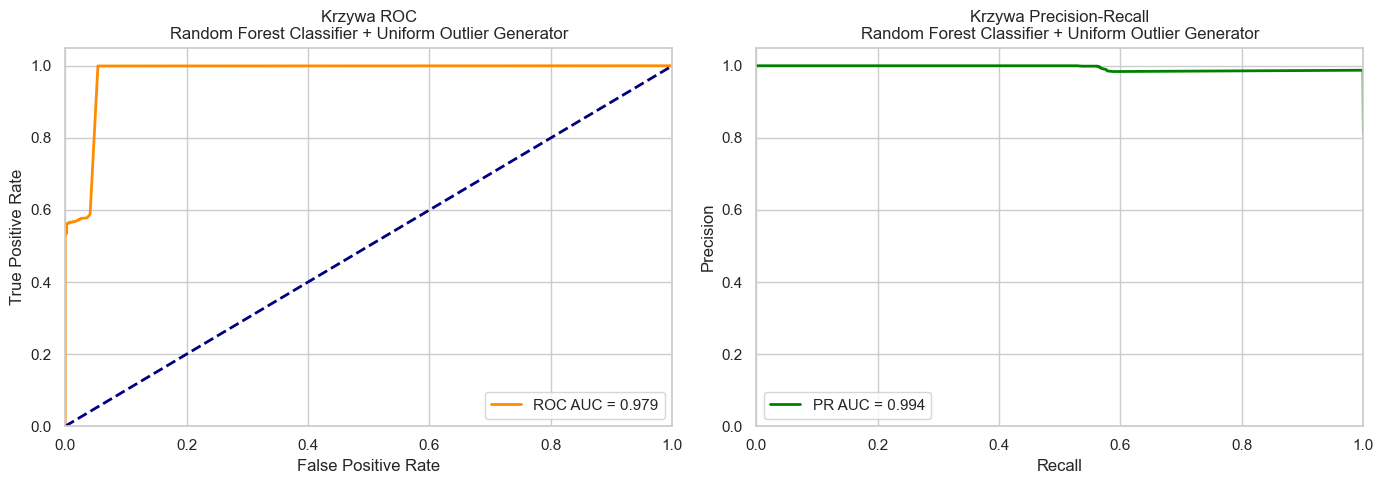

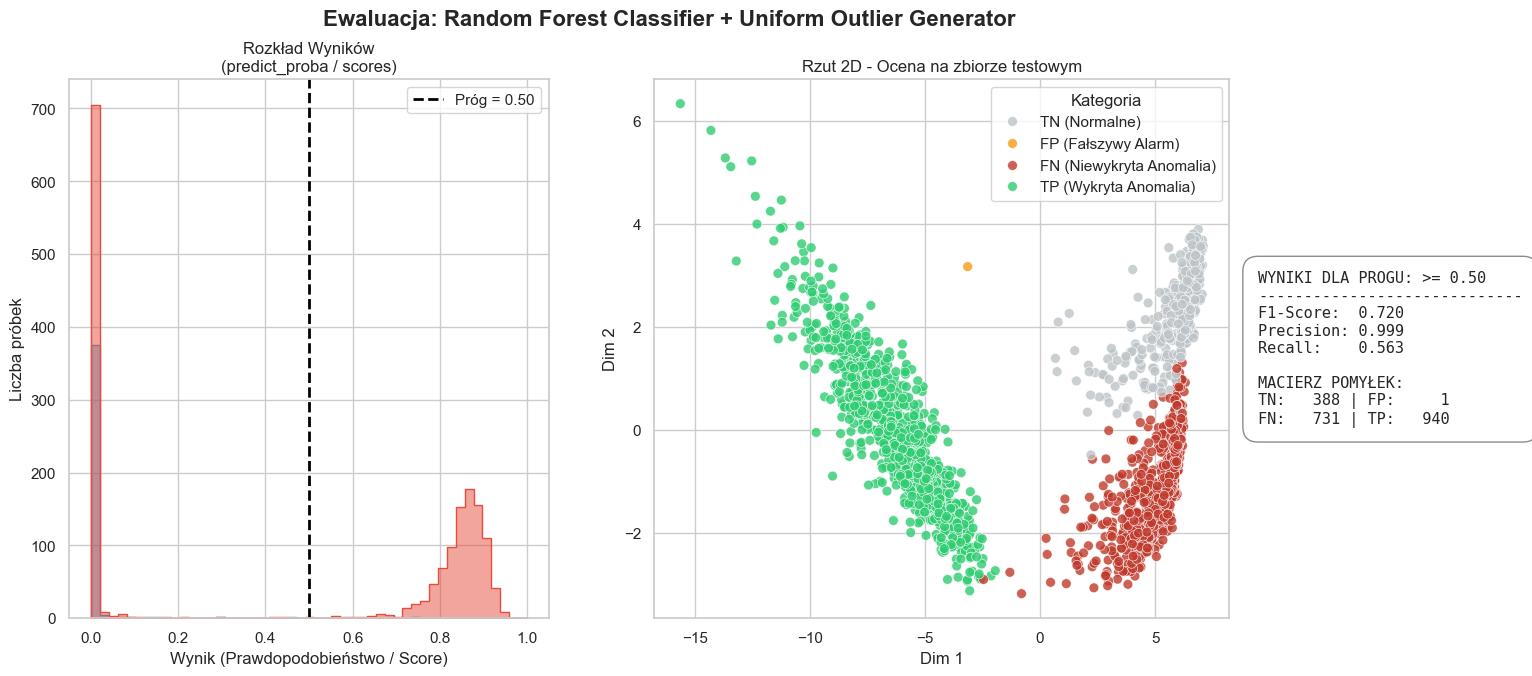


-------------------------------------------------------
Raport Klasyfikacji: Local Outlier Factor (Baseline)
-------------------------------------------------------
              precision    recall  f1-score   support

  Inlier (0)       0.71      1.00      0.83       389
 Outlier (1)       1.00      0.90      0.95      1671

    accuracy                           0.92      2060
   macro avg       0.85      0.95      0.89      2060
weighted avg       0.94      0.92      0.93      2060



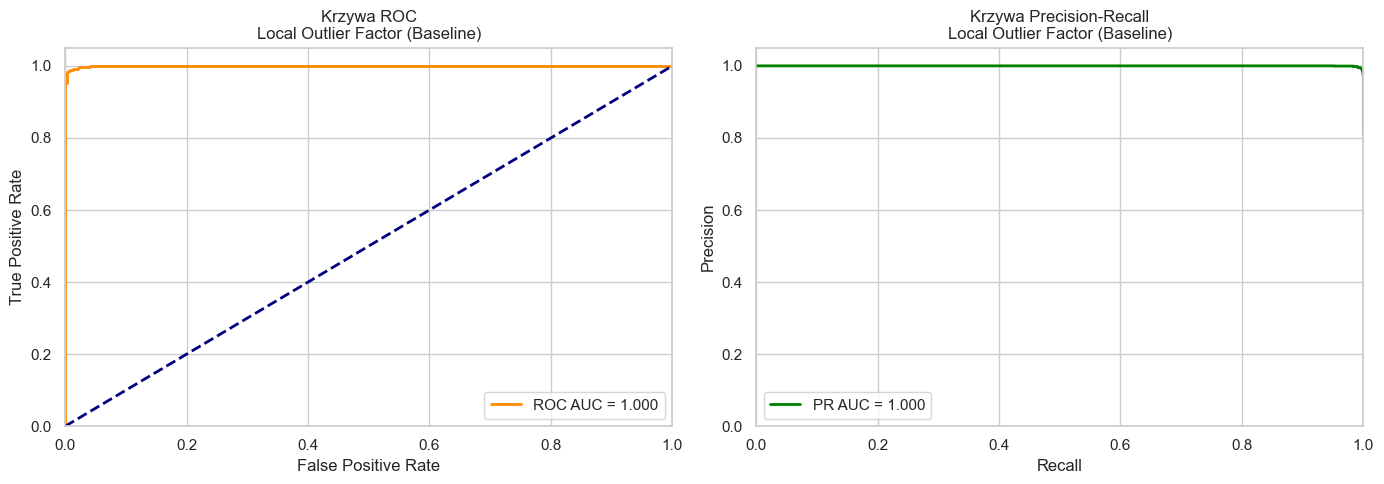

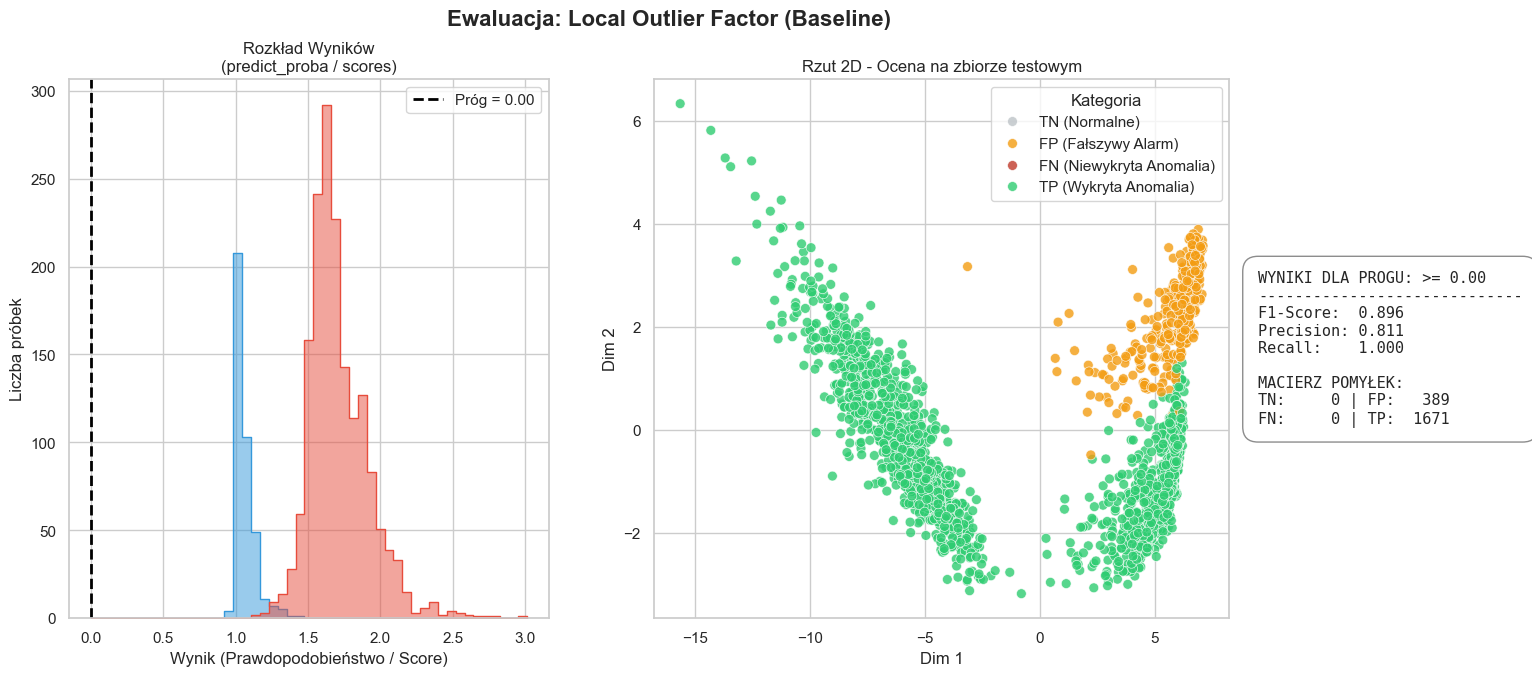

In [6]:
print("\nGenerowanie analiz pogłębionych (Dashboardy) dla zbioru HAR...")

df_eval, _ = load(Dataset.HAR)
X_eval = df_eval.drop(columns=["label"]).values
y_eval = df_eval["label"].values

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eval, y_eval, test_size=0.2, random_state=42, stratify=y_eval
)

X_train_normal_e = X_train_e[y_train_e == 0]

base = ensemble.RandomForestClassifier(random_state=42, n_jobs=-1)
model_gen = OutlierGenerator(estimator=base, outliers_fn="uniform", random_state=42)
model_gen.fit(X_train_normal_e)
preds_gen = model_gen.predict_proba(X_test_e)[:, 0]

plot_curves(
    model=model_gen, 
    X_test=X_test_e, 
    y_test=y_test_e, 
    model_name="Random Forest Classifier + Uniform Outlier Generator", 
    is_baseline=False
)
plot_evaluation_dashboard(
    X=X_test_e, 
    y_true=y_test_e, 
    y_preds=preds_gen, 
    model_name="Random Forest Classifier + Uniform Outlier Generator", 
    threshold=0.5
)

model_oneclass = neighbors.LocalOutlierFactor(novelty=True, n_jobs=-1)
model_oneclass.fit(X_train_normal_e)
preds_oneclass = -model_oneclass.score_samples(X_test_e)

plot_curves(
    model=model_oneclass, 
    X_test=X_test_e, 
    y_test=y_test_e, 
    model_name="Local Outlier Factor (Baseline)", 
    is_baseline=True
)
plot_evaluation_dashboard(
    X=X_test_e, 
    y_true=y_test_e, 
    y_preds=preds_oneclass, 
    model_name="Local Outlier Factor (Baseline)", 
    threshold=0.0
)

### Wnioski
* Pod maską oba analizowane modele radzą sobie fenomenalnie ze zrozumieniem struktury danych. Świadczą o tym bliskie perfekcji wartości ROC AUC (0.982 dla Random Forest i 1.000 dla LOF). Oznacza to, że niezależnie od metody, algorytmy niemal bezbłędnie potrafią ułożyć próbki w odpowiednim rankingu (prawdziwe anomalie otrzymują wyższe wyniki niż dane normalne).
* Histogramy ujawniają, że algorytmy operują w zupełnie innych dziedzinach matematycznych. Prawdopodobieństwa Random Forest zbijają się poniżej 1.0 (wymagając progu w okolicach np. 0.20-0.40, aby złapać ogon rozkładu), podczas gdy "scores" dla LOF w tym przypadku naturalnie lądują w przedziale od 1.0 do 3.0 (wymagając progu w luce rozkładu, np. wokół 1.20).